In [20]:
import pandas as pd
import plotly.express as px
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json

COLS = ["conversation_hash", "model", "timestamp", "turn",
        "language", "toxic", "redacted", "state", "country", "hashed_ip"]

df = pd.read_parquet("../Data/WildChatData/combined_data_tagged.parquet", columns=COLS)
print(df.shape)

(837989, 10)


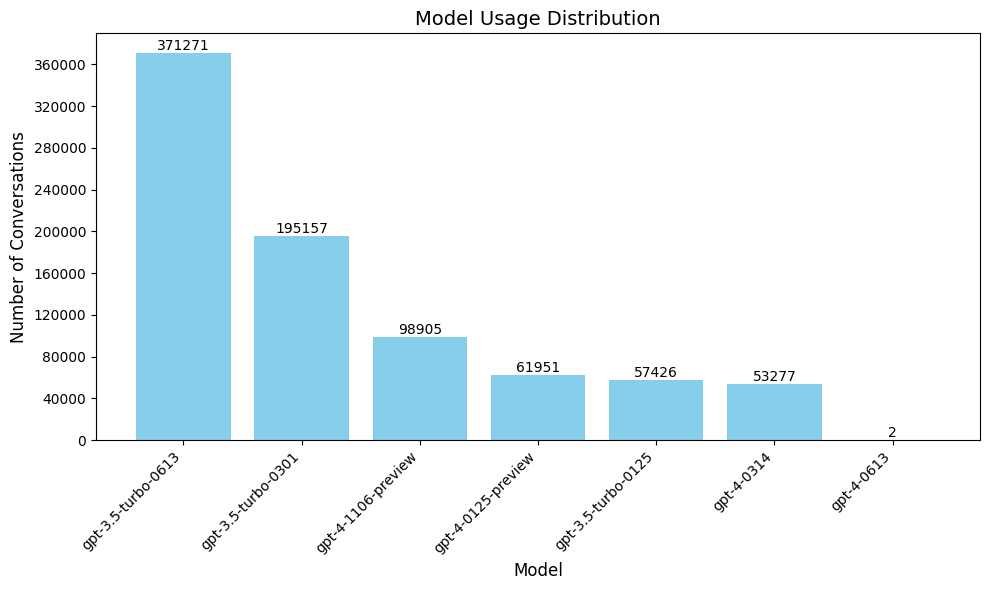

In [8]:
# ── Model usage bar graph ──────────────────────────────────────────────────────────────
def plot_model_usage_bar_graph(df):
    model_counts = df["model"].value_counts()
    plt.figure(figsize=(10, 6))
    bars = plt.bar(model_counts.index, model_counts.values, color="skyblue")
    plt.xlabel("Model", fontsize=12)
    plt.ylabel("Number of Conversations", fontsize=12)
    plt.title("Model Usage Distribution", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    
    # Add counts on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, height, f"{int(height)}", 
                 ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

plot_model_usage_bar_graph(df)


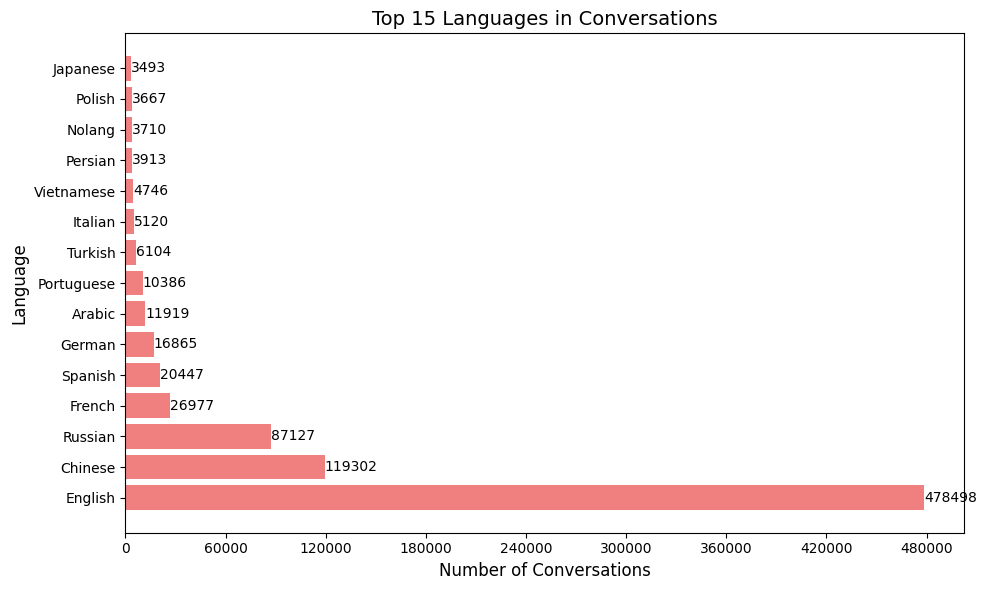

In [10]:
# -- Horizontal bar graph of top 15 languages
def plot_top_languages_bar_graph(df, top_n=15):
    language_counts = df["language"].value_counts().head(top_n)
    plt.figure(figsize=(10, 6))
    bars = plt.barh(language_counts.index, language_counts.values, color="lightcoral")
    plt.xlabel("Number of Conversations", fontsize=12)
    plt.ylabel("Language", fontsize=12)
    plt.title(f"Top {top_n} Languages in Conversations", fontsize=14)
    plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    
    # Add counts on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height() / 2.0, f"{int(width)}", 
                 ha='left', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

plot_top_languages_bar_graph(df)

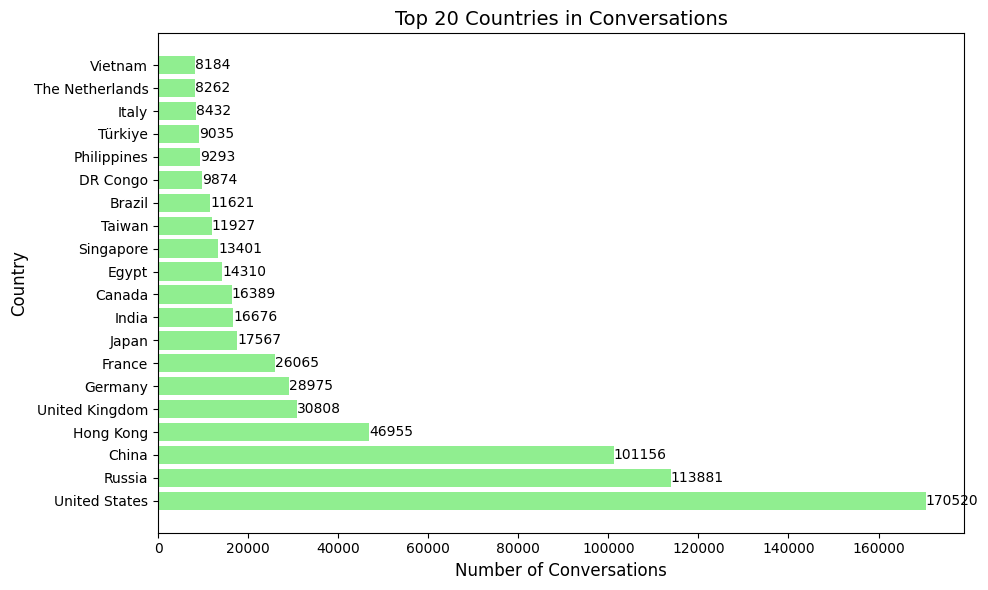

In [11]:
# ── Top 20 Countries ──────────────────────────────────────────────────────────────
def plot_top_countries_bar_graph(df, top_n=20):
    country_counts = df["country"].value_counts().head(top_n)
    plt.figure(figsize=(10, 6))
    bars = plt.barh(country_counts.index, country_counts.values, color="lightgreen")
    plt.xlabel("Number of Conversations", fontsize=12)
    plt.ylabel("Country", fontsize=12)
    plt.title(f"Top {top_n} Countries in Conversations", fontsize=14)
    plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    
    # Add counts on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height() / 2.0, f"{int(width)}", 
                 ha='left', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

plot_top_countries_bar_graph(df)

/var/folders/tl/4t09mlnj77n3jq62vywtbd940000gp/T/ipykernel_28684/3543240458.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["timestamp"].dt.to_period("M")


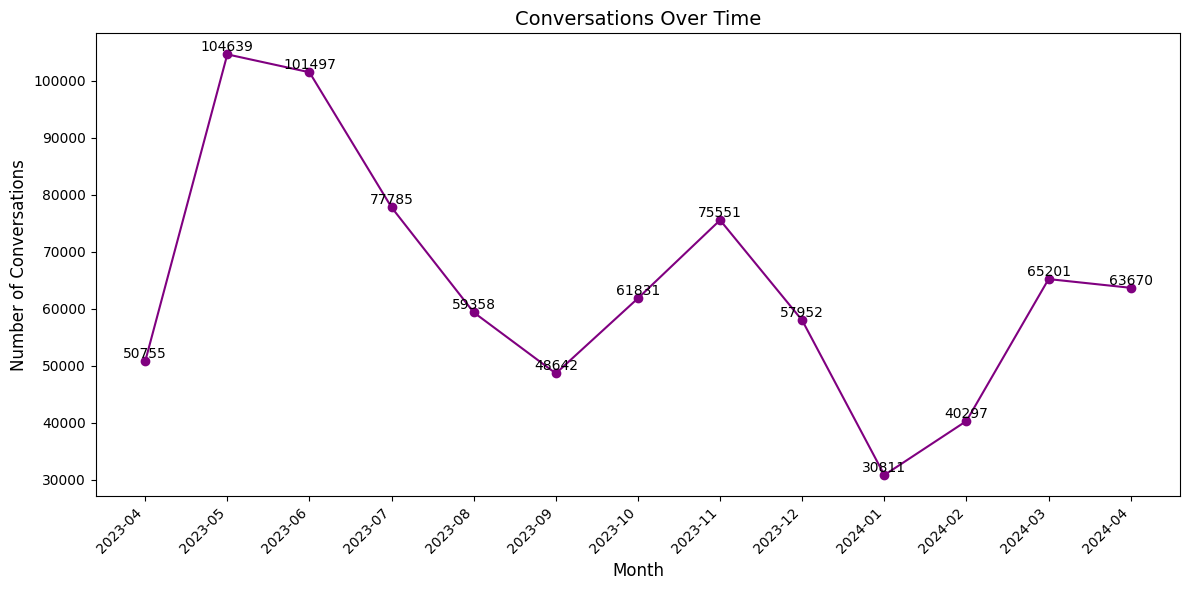

In [17]:
# ── Conversation per-month line chart ──────────────────────────────────────────────────────────────

def plot_conversations_over_time(df):
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["month"] = df["timestamp"].dt.to_period("M")
    monthly_counts = df.groupby("month").size()
    
    plt.figure(figsize=(12, 6))
    plt.plot(monthly_counts.index.astype(str), monthly_counts.values, marker="o", color="purple")
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Number of Conversations", fontsize=12)
    plt.title("Conversations Over Time", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    
    # Add counts on points
    for i, count in enumerate(monthly_counts.values):
        plt.text(i, count, f"{int(count)}", ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

plot_conversations_over_time(df)

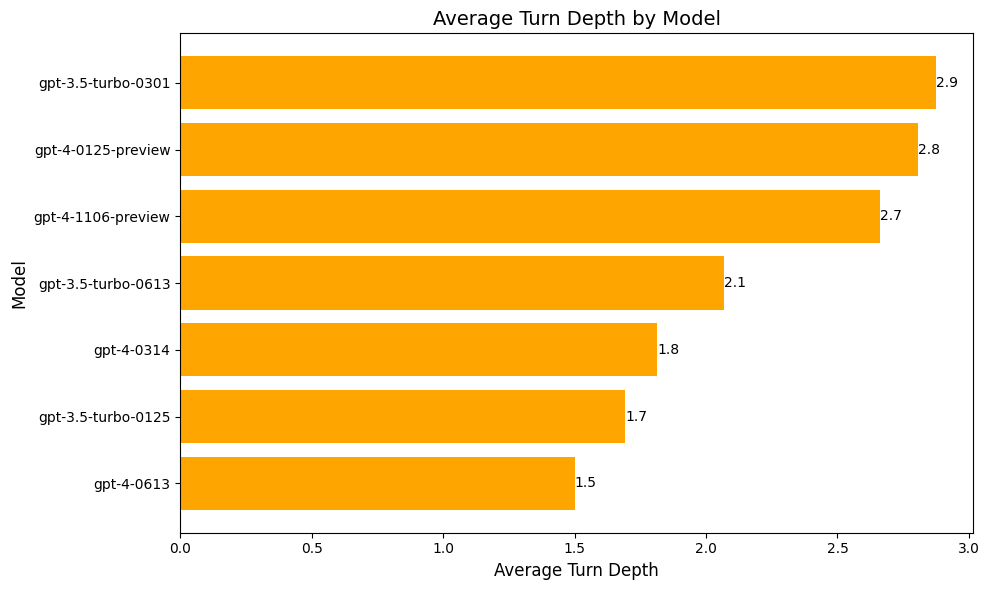

In [18]:
# ── Turn depth by model ──────────────────────────────────────────────────────────────

def plot_turn_depth_by_model(df):
    turn_depth = df.groupby("model")["turn"].mean().sort_values()
    
    plt.figure(figsize=(10, 6))
    bars = plt.barh(turn_depth.index, turn_depth.values, color="orange")
    plt.xlabel("Average Turn Depth", fontsize=12)
    plt.ylabel("Model", fontsize=12)
    plt.title("Average Turn Depth by Model", fontsize=14)
    
    # Add average turn depth on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height() / 2.0, f"{width:.1f}", 
                 ha='left', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

plot_turn_depth_by_model(df)

In [21]:
# ── conversations by country choropleth ──────────────────────────────────────────────────────────────

def plot_countrychat_choropleth(df):
    country_counts = df["country"].value_counts().reset_index()
    country_counts.columns = ["country", "count"]
    
    fig = px.choropleth(country_counts, locations="country", locationmode="country names",
                        color="count", color_continuous_scale="Viridis",
                        title="Conversations by Country")
    fig.update_layout(geo=dict(showframe=False, showcoastlines=False))
    fig.show()

plot_countrychat_choropleth(df)

/var/folders/tl/4t09mlnj77n3jq62vywtbd940000gp/T/ipykernel_28684/3659049939.py:7: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(country_counts, locations="country", locationmode="country names",
